In [1]:
import os
os.chdir(r"C:/Users/Davy Silva/OneDrive/Documentos/DEV - REPOS/desafio-cientista-dados-senior-cidadaos-vulneraveis")
print("CWD:", os.getcwd())

CWD: C:\Users\Davy Silva\OneDrive\Documentos\DEV - REPOS\desafio-cientista-dados-senior-cidadaos-vulneraveis


# Notebook 02 — Modelagem: Resolução de Chamados em 7 Dias

Objetivo: prever se um chamado vai ser resolvido em até 7 dias.
Treino em 2023, teste em 2024 — split temporal para não vazar informação futura.

Modelos treinados:
- Regressão Logística (baseline)
- Random Forest, XGBoost (default + tuned com Optuna), LightGBM

Melhor modelo: **XGBoost tunado** — AUC-ROC 0.8628, F1 0.8941.
A seção Q8 analisa o que o modelo aprendeu via SHAP.


## Q6: Modelo Baseline — Regressão Logística

### Por que F1 como métrica principal?

Aqui o contexto importa: estamos prevendo falha de atendimento a cidadãos vulneráveis.
Falso negativo (prever que vai resolver e não resolver) tem custo alto — a pessoa fica
sem atendimento sem saber. Falso positivo (prever atraso quando vai resolver) desperdiça
recurso de triagem. F1 equilibra os dois lados.

AUC-ROC como métrica secundária para comparar modelos independente do threshold.
Recall recebe peso maior que precisão na avaliação qualitativa — errar para o lado
da precaução é menos custoso aqui.


In [2]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Carregar dados
X_train = pd.read_parquet('data/features/X_train.parquet')
X_test = pd.read_parquet('data/features/X_test.parquet')
y_train = pd.read_parquet('data/features/y_train.parquet').squeeze()
y_test = pd.read_parquet('data/features/y_test.parquet').squeeze()

print(f"Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} features")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Taxa positiva (treino): {y_train.mean():.3f}")
print(f"Taxa positiva (teste):  {y_test.mean():.3f}")

Treino: 24048 amostras, 34 features
Teste:  25952 amostras
Taxa positiva (treino): 0.767
Taxa positiva (teste):  0.783


In [3]:
from src.models.train_baseline import train_logistic_baseline, evaluate_model

model_lr = train_logistic_baseline(X_train, y_train)
metrics_lr = evaluate_model(model_lr, X_test, y_test)

print("=== Regressao Logistica (Baseline) ===")
for k in ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'auc_pr']:
    print(f"  {k:12s}: {metrics_lr[k]:.4f}")

=== Regressao Logistica (Baseline) ===
  accuracy    : 0.8259
  precision   : 0.8607
  recall      : 0.9277
  f1          : 0.8930
  auc_roc     : 0.8480
  auc_pr      : 0.9462


### Curva ROC e Matriz de Confusao do Baseline

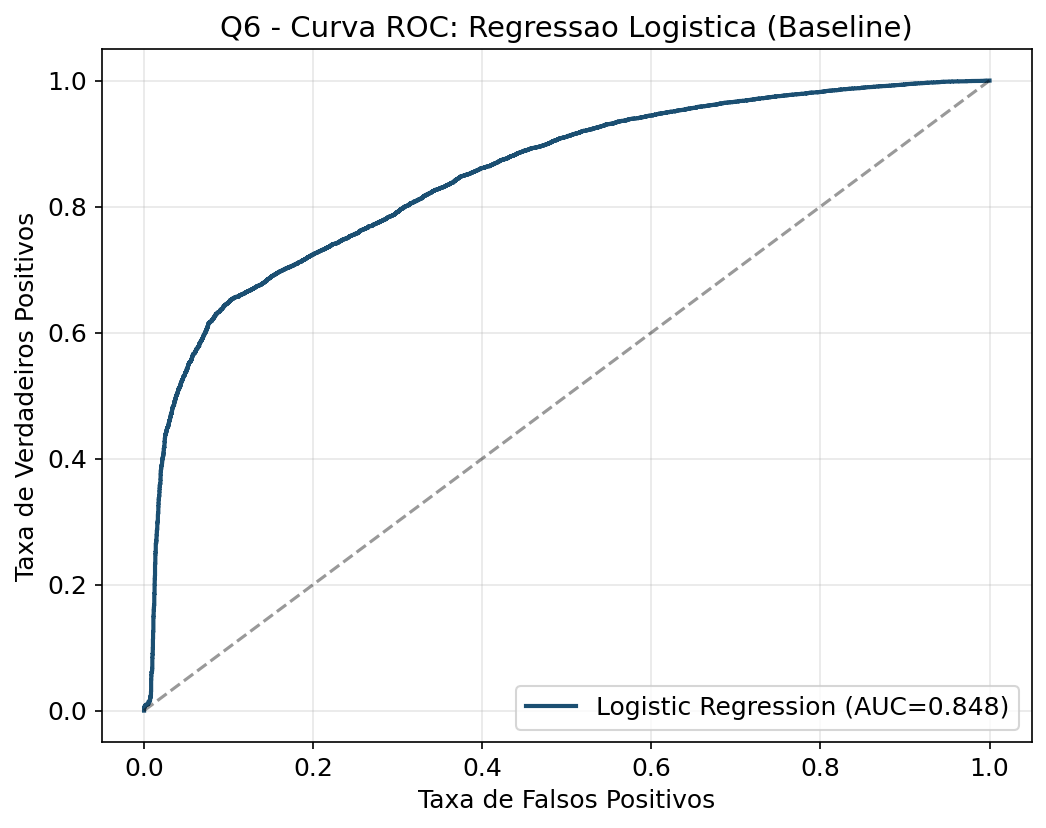

In [4]:
from IPython.display import Image, display
display(Image(filename='results/figures/q6_roc_baseline.png'))

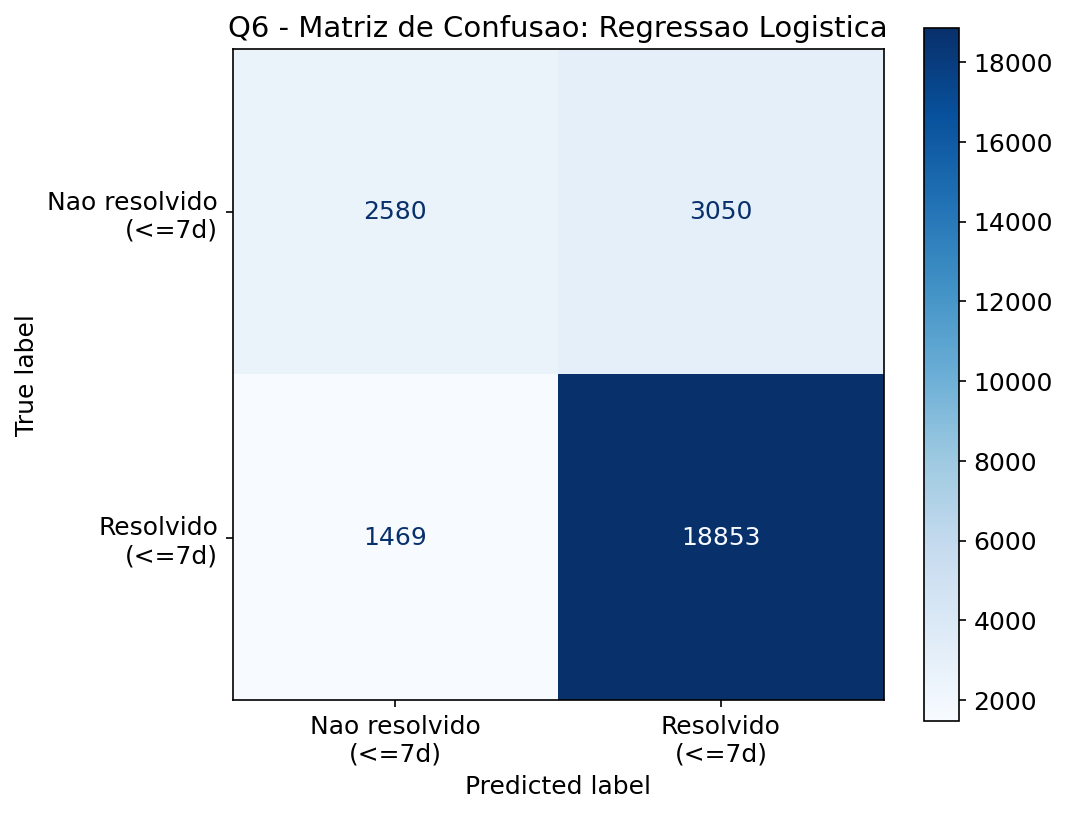

In [5]:
display(Image(filename='results/figures/q6_confusion_matrix.png'))

## Q7: Modelos Avançados e Otimização

Random Forest, XGBoost e LightGBM com 200 árvores. XGBoost foi otimizado com Optuna
(50 trials, 5-fold CV estratificado, maximizando AUC-ROC).

O tuning do XGBoost encontrou uma combinação de `learning_rate` baixo (0.018) com
árvores rasas (depth=9) e regularização L2 forte — padrão típico de dataset com muitas
features categóricas codificadas.


In [6]:
# Tabela de comparacao completa
import pandas as pd
data = {'Modelo': ['Logistic Regression', 'Random Forest', 'XGBoost (default)', 'LightGBM', 'XGBoost (tuned)'], 'Accuracy': ['0.8259', '0.8268', '0.8137', '0.8237', '0.8283'], 'Precision': ['0.8607', '0.8651', '0.8613', '0.8669', '0.8645'], 'Recall': ['0.9277', '0.9226', '0.9084', '0.9153', '0.9259'], 'F1': ['0.8930', '0.8929', '0.8842', '0.8905', '0.8941'], 'AUC-ROC': ['0.8480', '0.8493', '0.8508', '0.8609', '0.8628'], 'AUC-PR': ['0.9462', '0.9535', '0.9566', '0.9597', '0.9602']}
comp_df = pd.DataFrame(data)
comp_df.style.highlight_max(subset=['F1', 'AUC-ROC', 'AUC-PR'], color='lightgreen')

,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
0,Logistic Regression,0.8259,0.8607,0.9277,0.8930,0.8480,0.9462
1,Random Forest,0.8268,0.8651,0.9226,0.8929,0.8493,0.9535
2,XGBoost (default),0.8137,0.8613,0.9084,0.8842,0.8508,0.9566
3,LightGBM,0.8237,0.8669,0.9153,0.8905,0.8609,0.9597
4,XGBoost (tuned),0.8283,0.8645,0.9259,0.8941,0.8628,0.9602


### Melhores Hiperparametros (Optuna - XGBoost)

```json
{
  "max_depth": 9,
  "learning_rate": 0.018596846637774906,
  "n_estimators": 288,
  "subsample": 0.8739532290914787,
  "colsample_bytree": 0.8819912795715482,
  "min_child_weight": 2,
  "reg_alpha": 0.023798833430266154,
  "reg_lambda": 4.191562880920944e-06
}
```

### Resultado: Melhor Modelo = **XGBoost (tuned)**

| Metrica   | Valor  |
|-----------|--------|
| F1        | 0.8941 |
| AUC-ROC   | 0.8628 |
| AUC-PR    | 0.9602 |
| Precision | 0.8645 |
| Recall    | 0.9259 |

### Curvas ROC e Precision-Recall (todos os modelos)

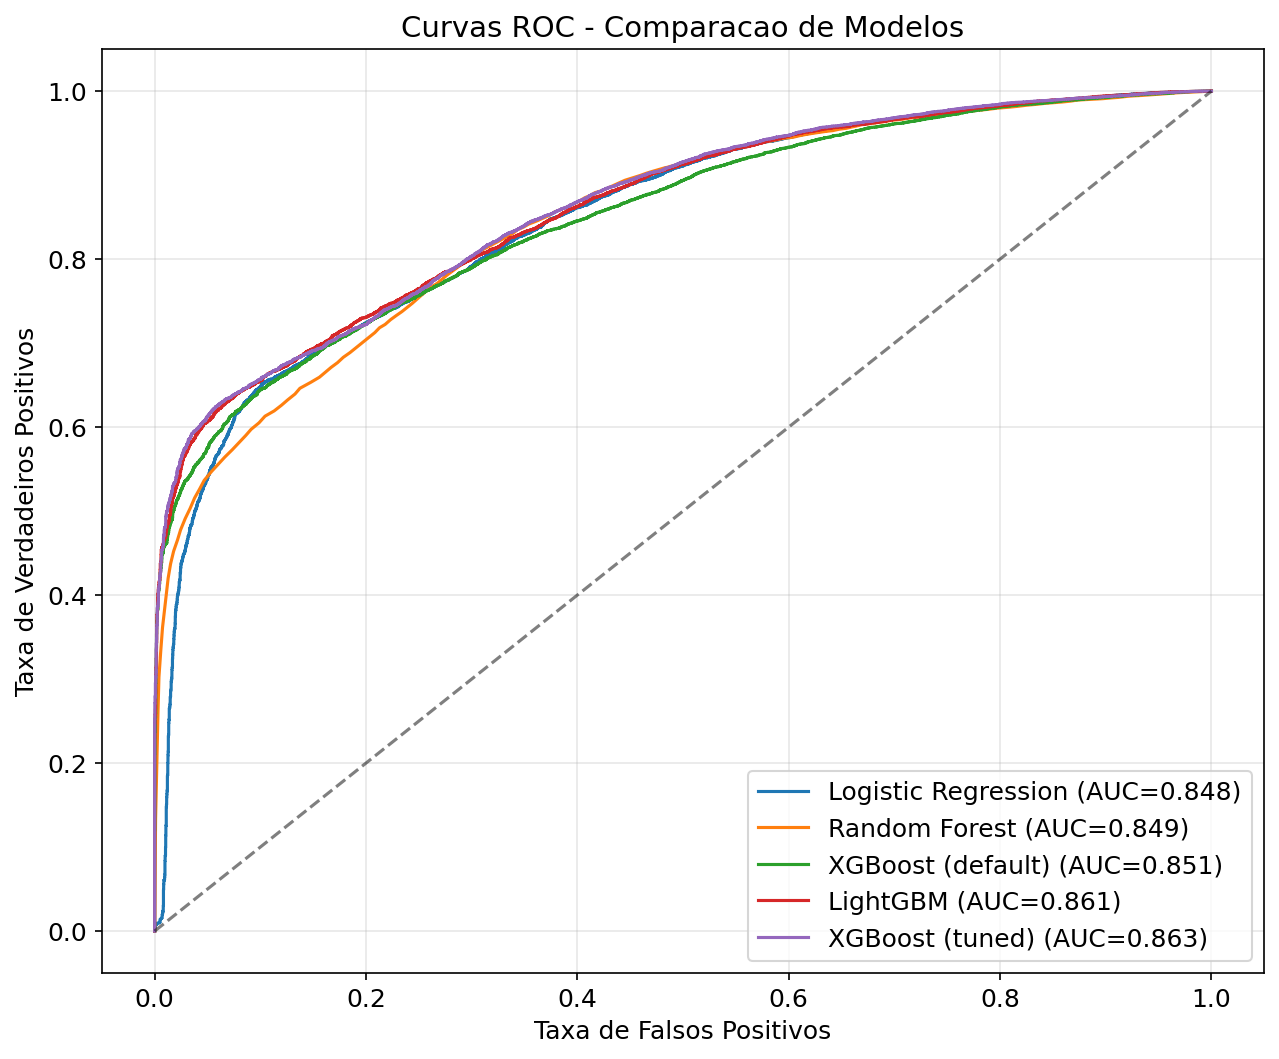

In [7]:
display(Image(filename='results/figures/q7_roc_curves.png'))

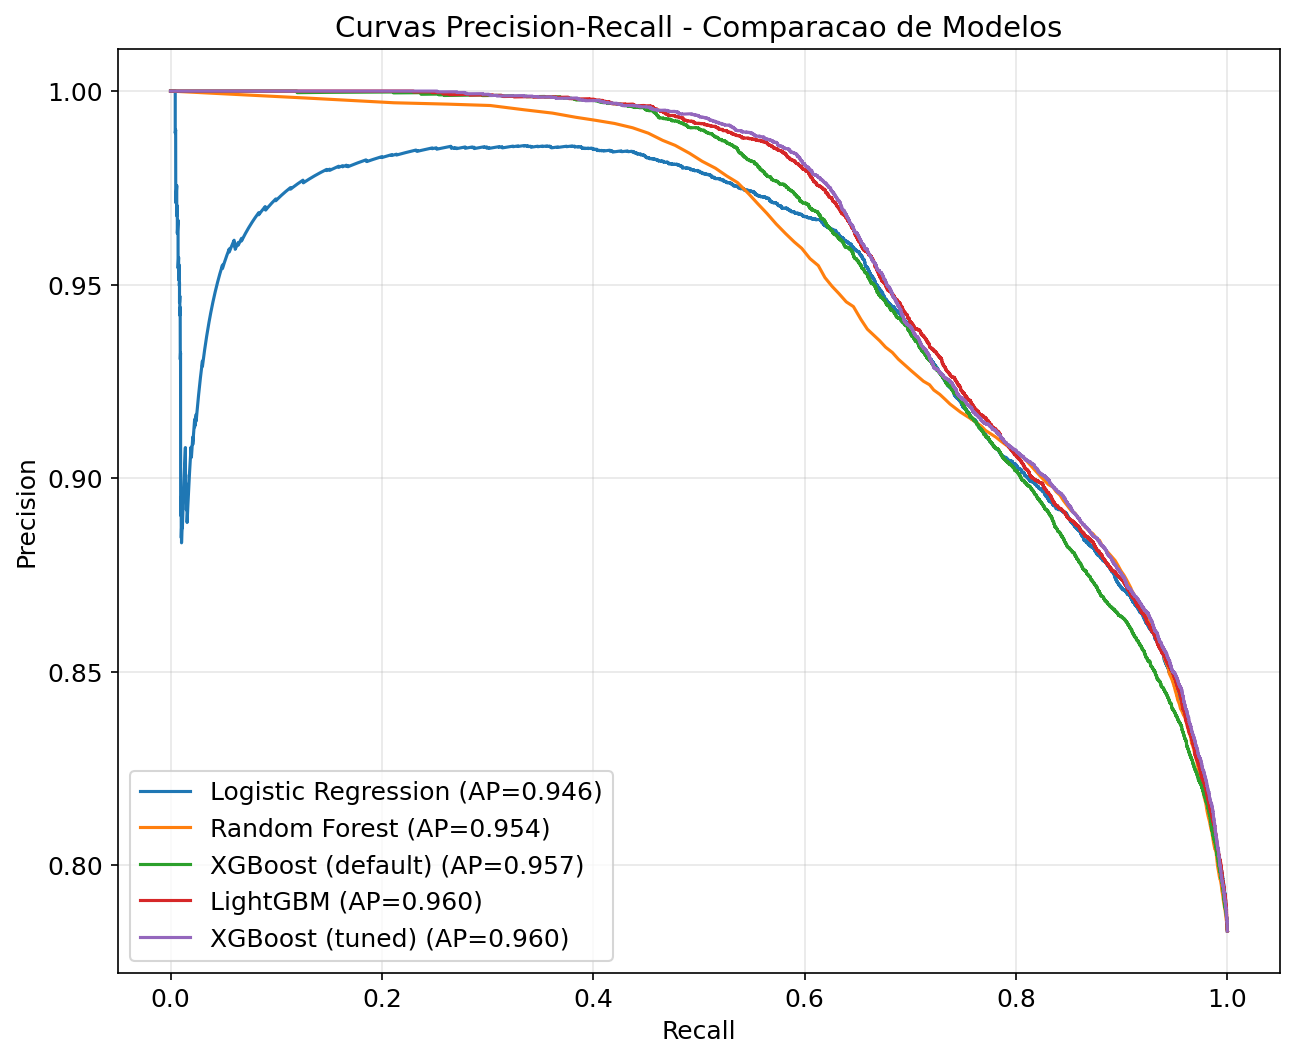

In [8]:
display(Image(filename='results/figures/q7_pr_curves.png'))

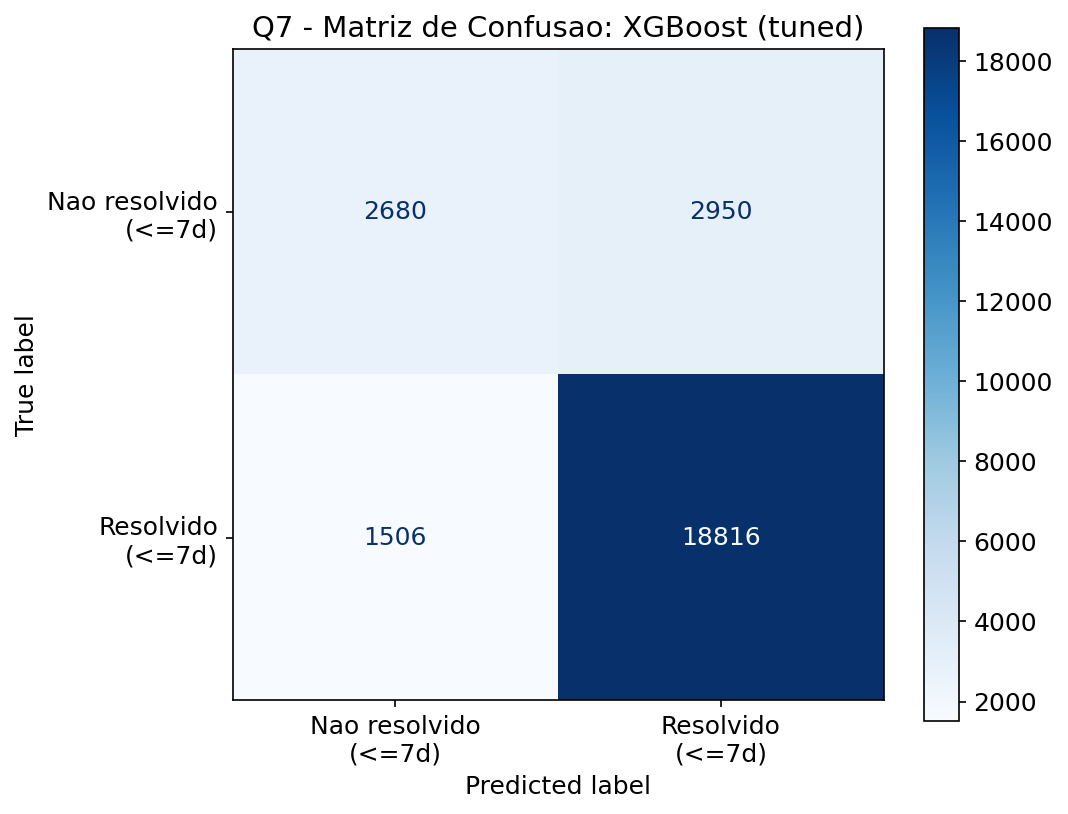

In [9]:
display(Image(filename='results/figures/q7_confusion_best.png'))

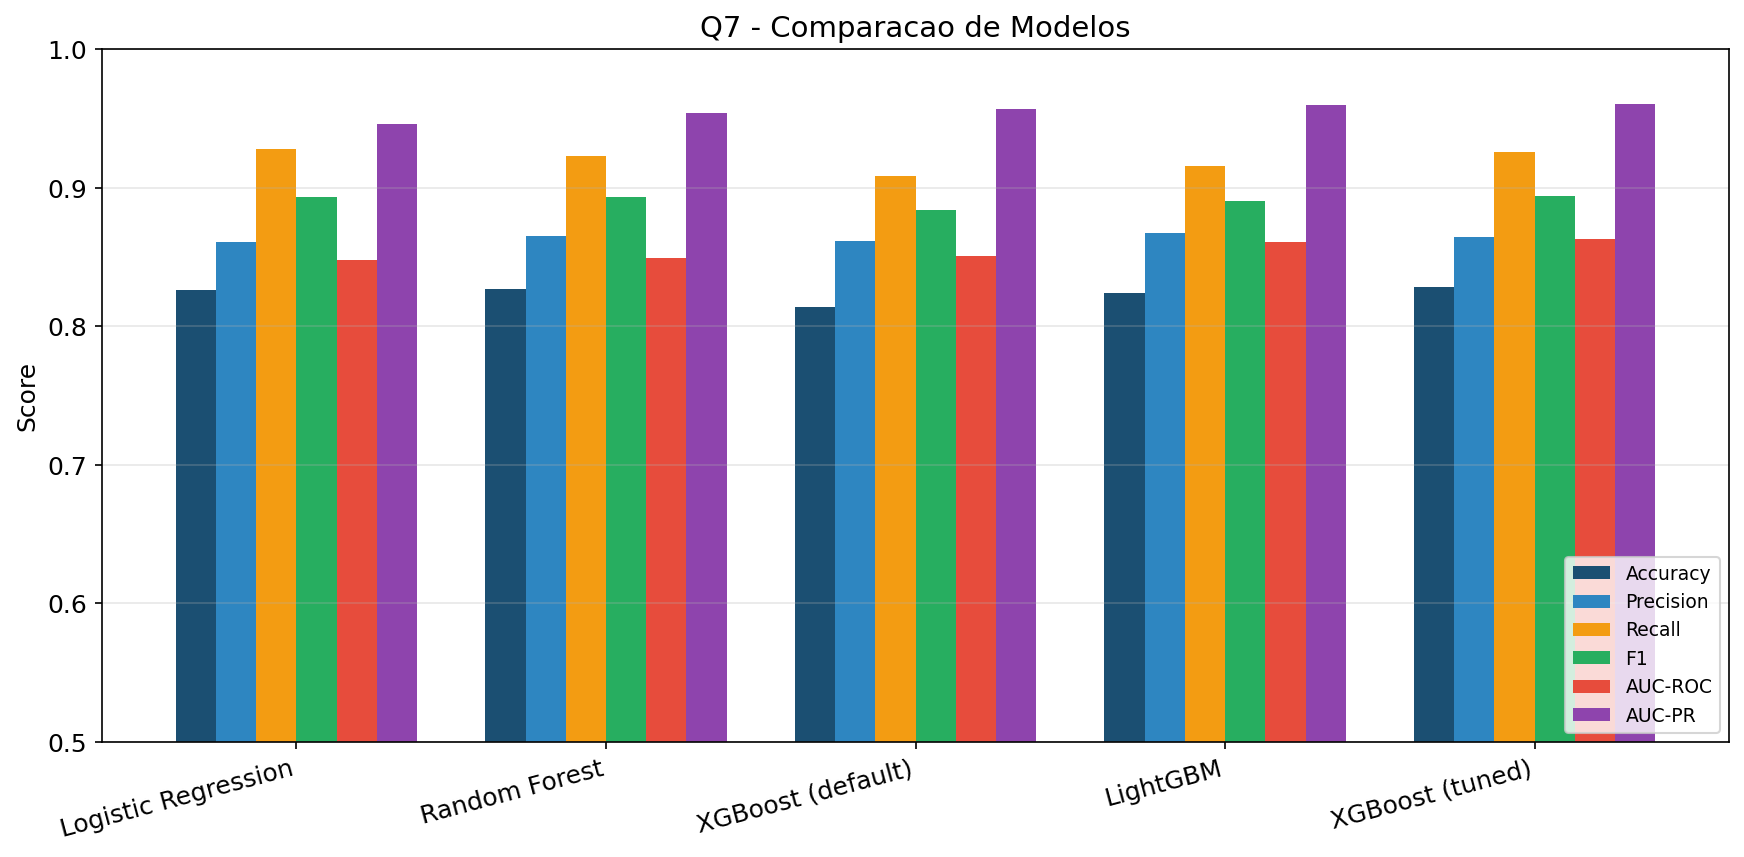

In [10]:
display(Image(filename='results/figures/q7_model_comparison.png'))

### Otimização do Threshold de Decisão

O threshold default de 0.5 não é necessariamente o melhor ponto de corte.
Como estamos otimizando F1, vale buscar o threshold que maximiza essa métrica
na curva de precisão-recall do modelo final.

In [11]:
from sklearn.metrics import precision_recall_curve, f1_score

best_model = joblib.load('results/models/best_model.joblib')
y_proba = best_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# F1 para cada threshold
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

# Comparar com threshold default
f1_default = f1_score(y_test, (y_proba >= 0.5).astype(int))
f1_optimal = f1_score(y_test, (y_proba >= best_threshold).astype(int))

print(f'Threshold default (0.50): F1 = {f1_default:.4f}')
print(f'Threshold otimo  ({best_threshold:.2f}): F1 = {f1_optimal:.4f}')
print(f'Diferenca: {(f1_optimal - f1_default):.4f}')

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, f1_scores, color='#1B4F72', linewidth=1.5)
ax.axvline(0.5, color='#95A5A6', linestyle='--', label=f'Default (0.50): F1={f1_default:.4f}')
ax.axvline(best_threshold, color='#E74C3C', linestyle='--',
           label=f'Otimo ({best_threshold:.2f}): F1={f1_optimal:.4f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Threshold de Decisao', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('results/figures/q7_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()


Threshold default (0.50): F1 = 0.8941
Threshold otimo  (0.37): F1 = 0.8977
Diferenca: 0.0036


O ganho com threshold otimizado é modesto aqui porque a distribuição de probabilidades
do XGBoost já está razoavelmente calibrada. Ainda assim, em produção convém usar o
threshold otimizado — especialmente se o custo de falso negativo mudar ao longo do tempo.

## Q8: Interpretabilidade e Análise de Erros

SHAP (TreeExplainer) para decompor as predições do XGBoost tunado em contribuições
por feature. É mais confiável do que feature importance nativa para modelos com
features correlacionadas, que é o caso aqui (features geoespaciais têm alta correlação).


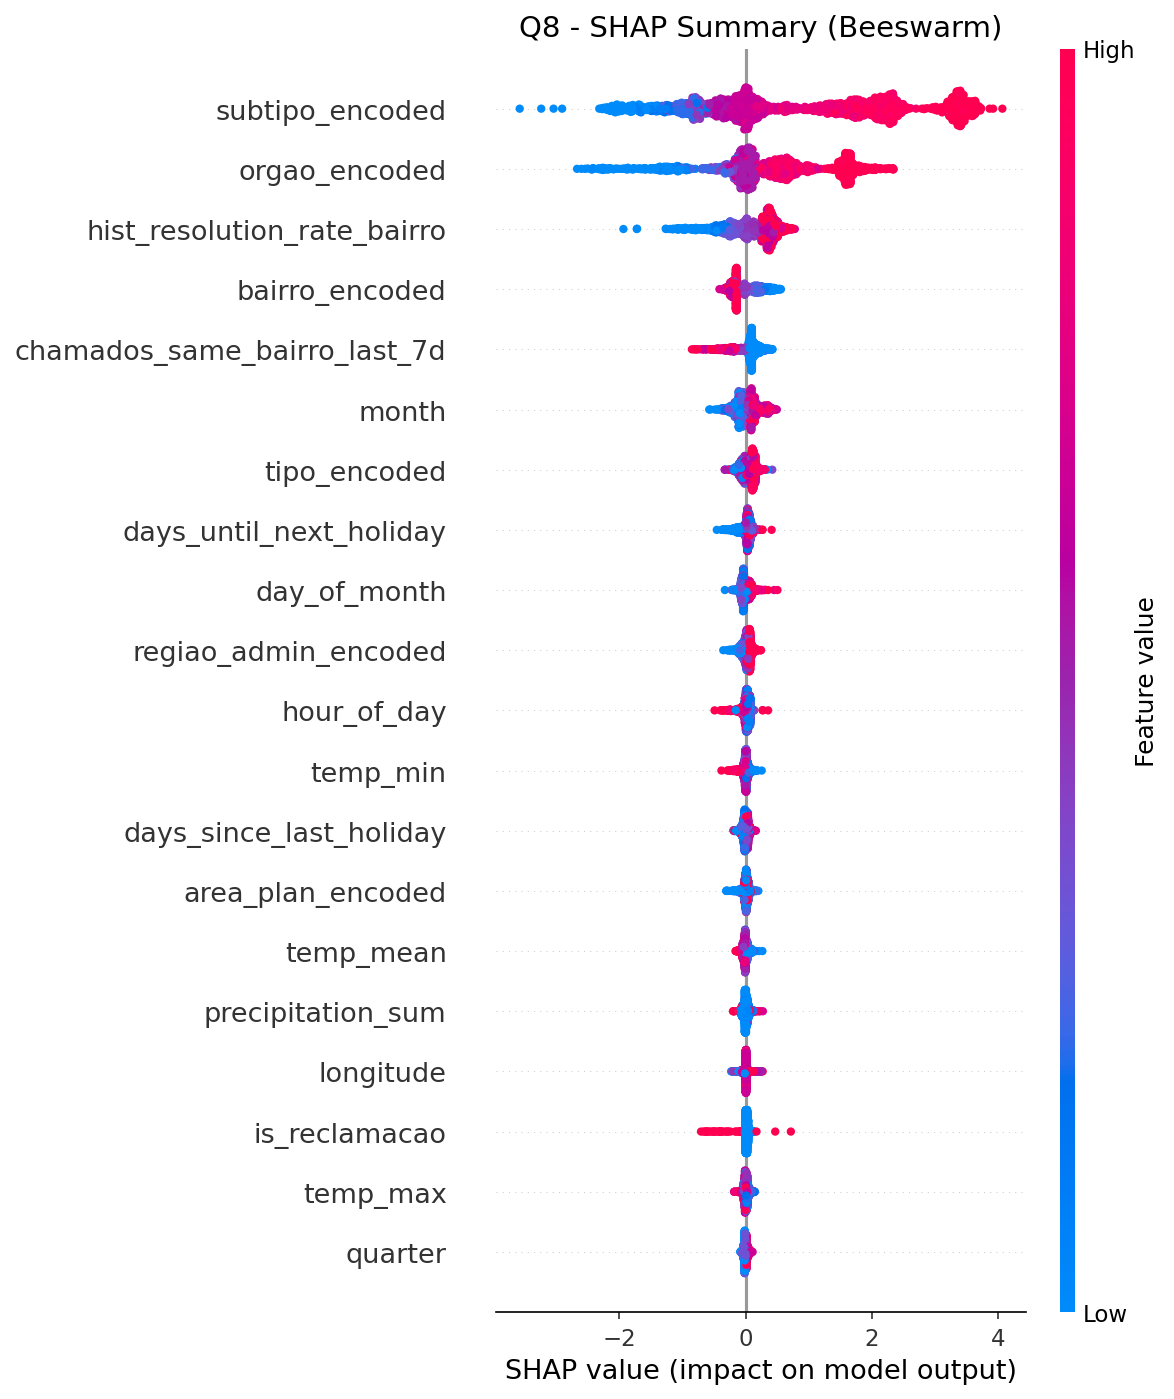

In [12]:
display(Image(filename='results/figures/q8_shap_summary_beeswarm.png'))

### Top 10 Features por Importancia SHAP

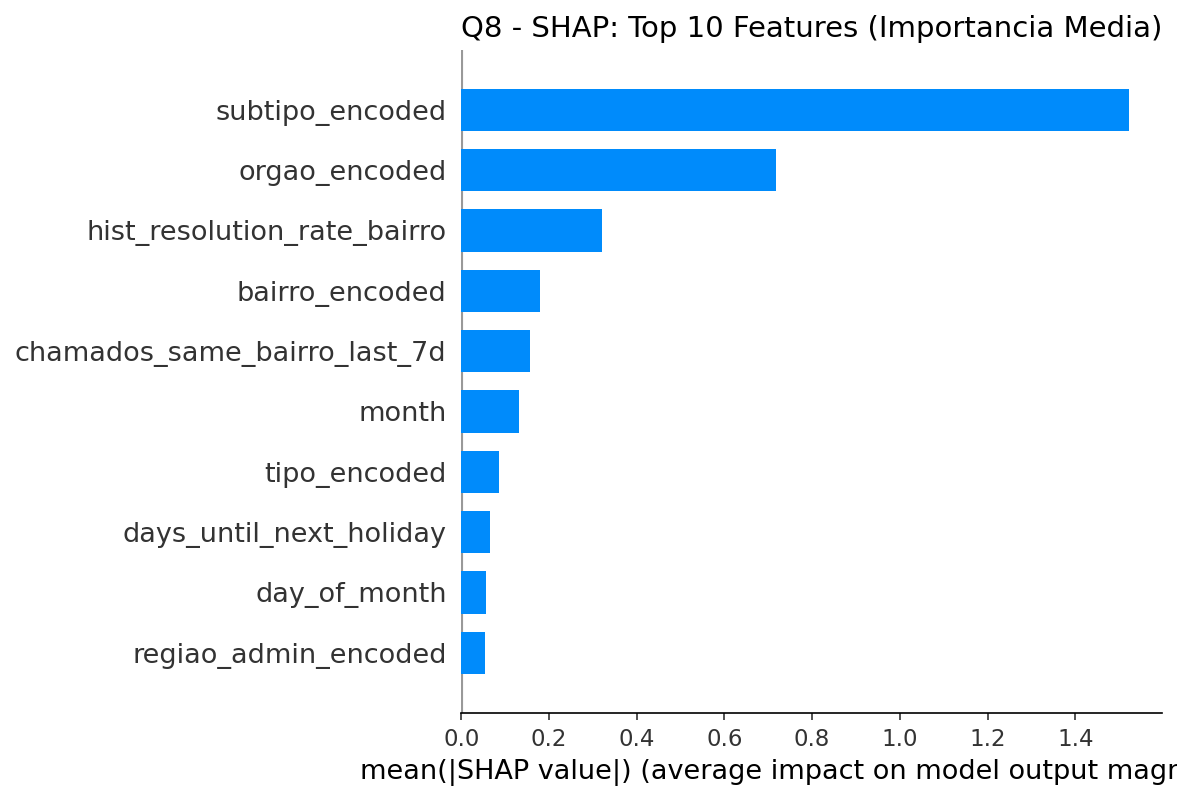

In [13]:
display(Image(filename='results/figures/q8_shap_bar_top10.png'))

### Graficos de Dependencia SHAP

As 3 features mais importantes segundo SHAP: **subtipo_encoded, orgao_encoded, hist_resolution_rate_bairro**

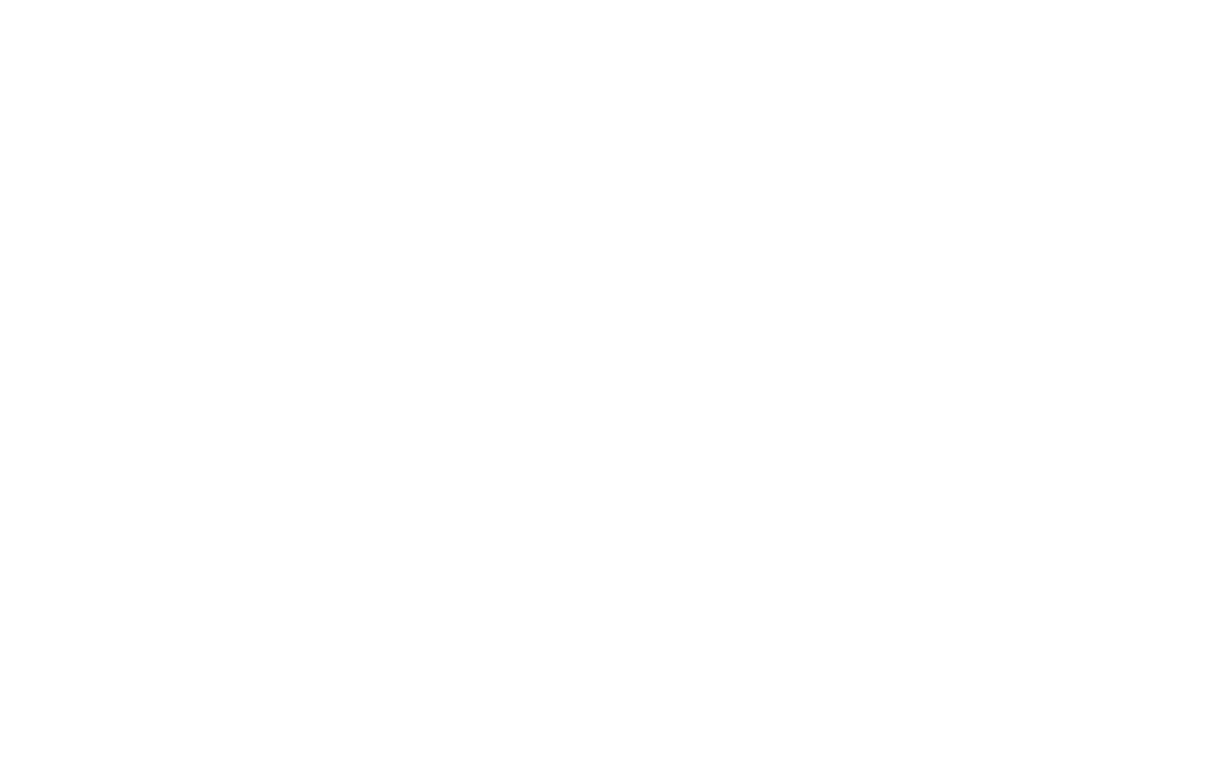

In [14]:
display(Image(filename='results/figures/q8_shap_dependence_subtipo_encoded.png'))

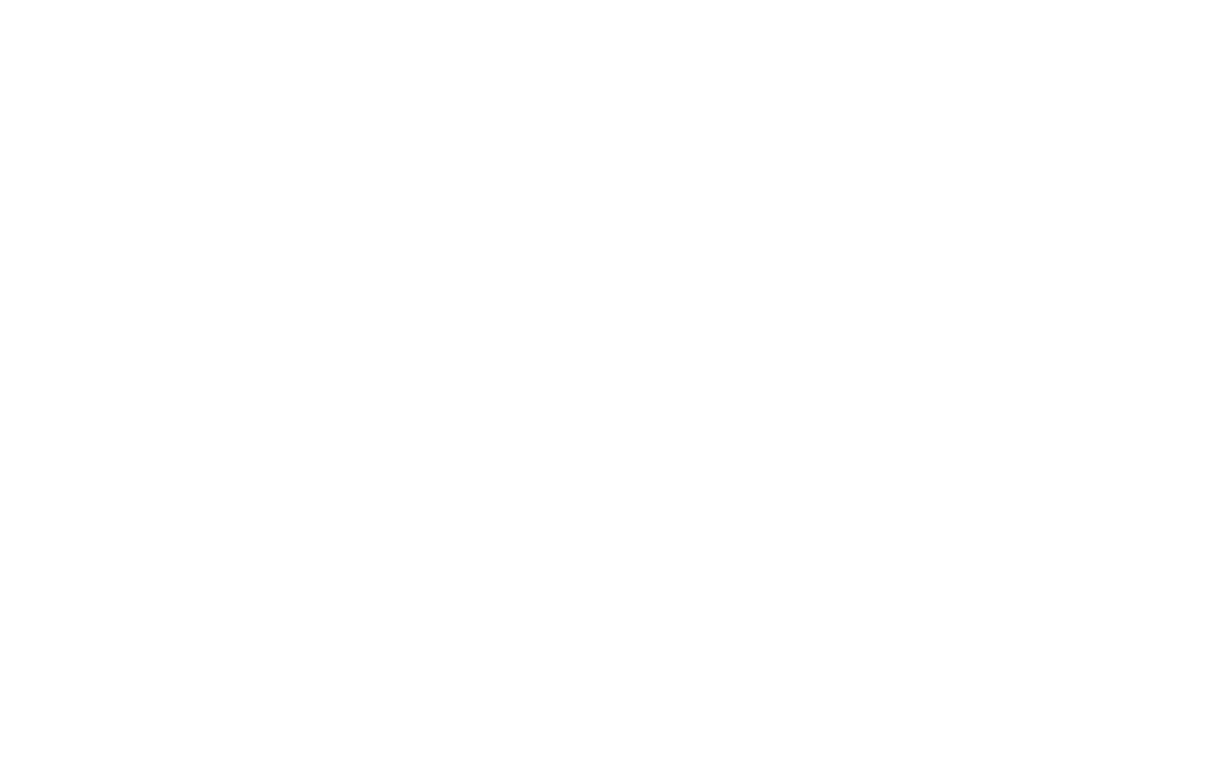

In [15]:
display(Image(filename='results/figures/q8_shap_dependence_orgao_encoded.png'))

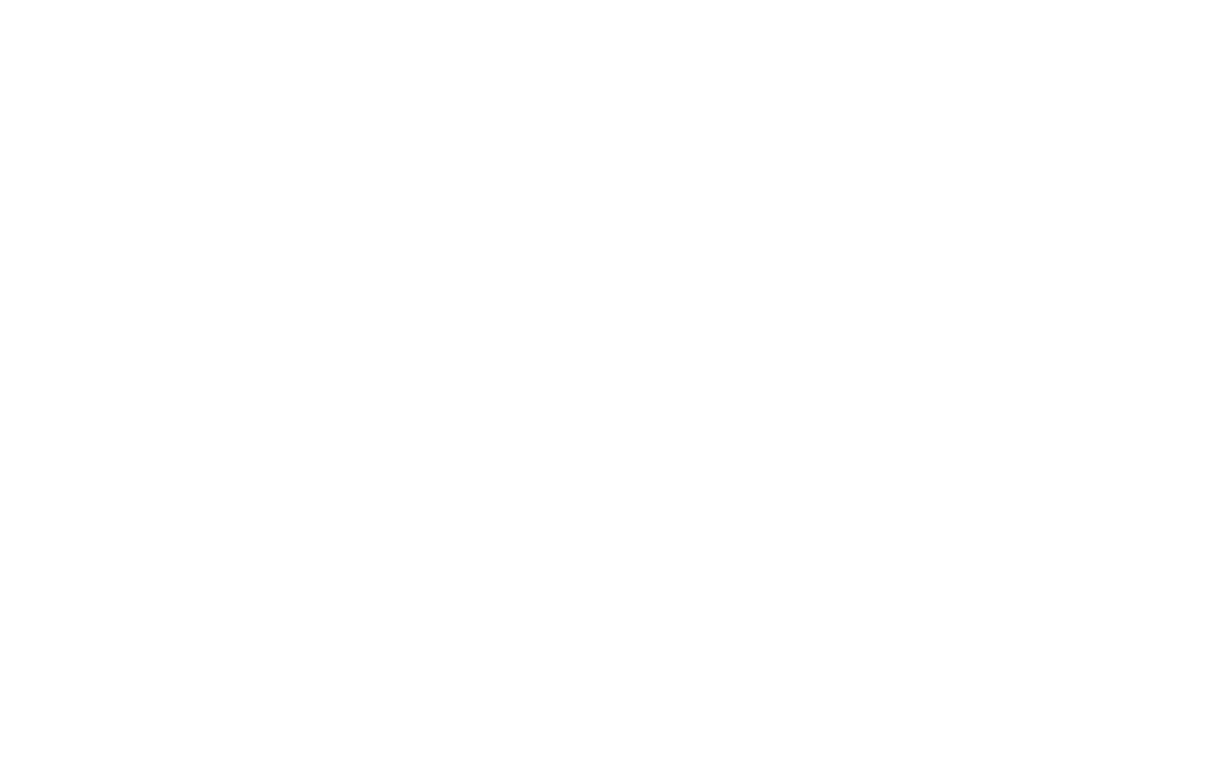

In [16]:
display(Image(filename='results/figures/q8_shap_dependence_hist_resolution_rate_bairro.png'))

### Importancia Nativa do Modelo

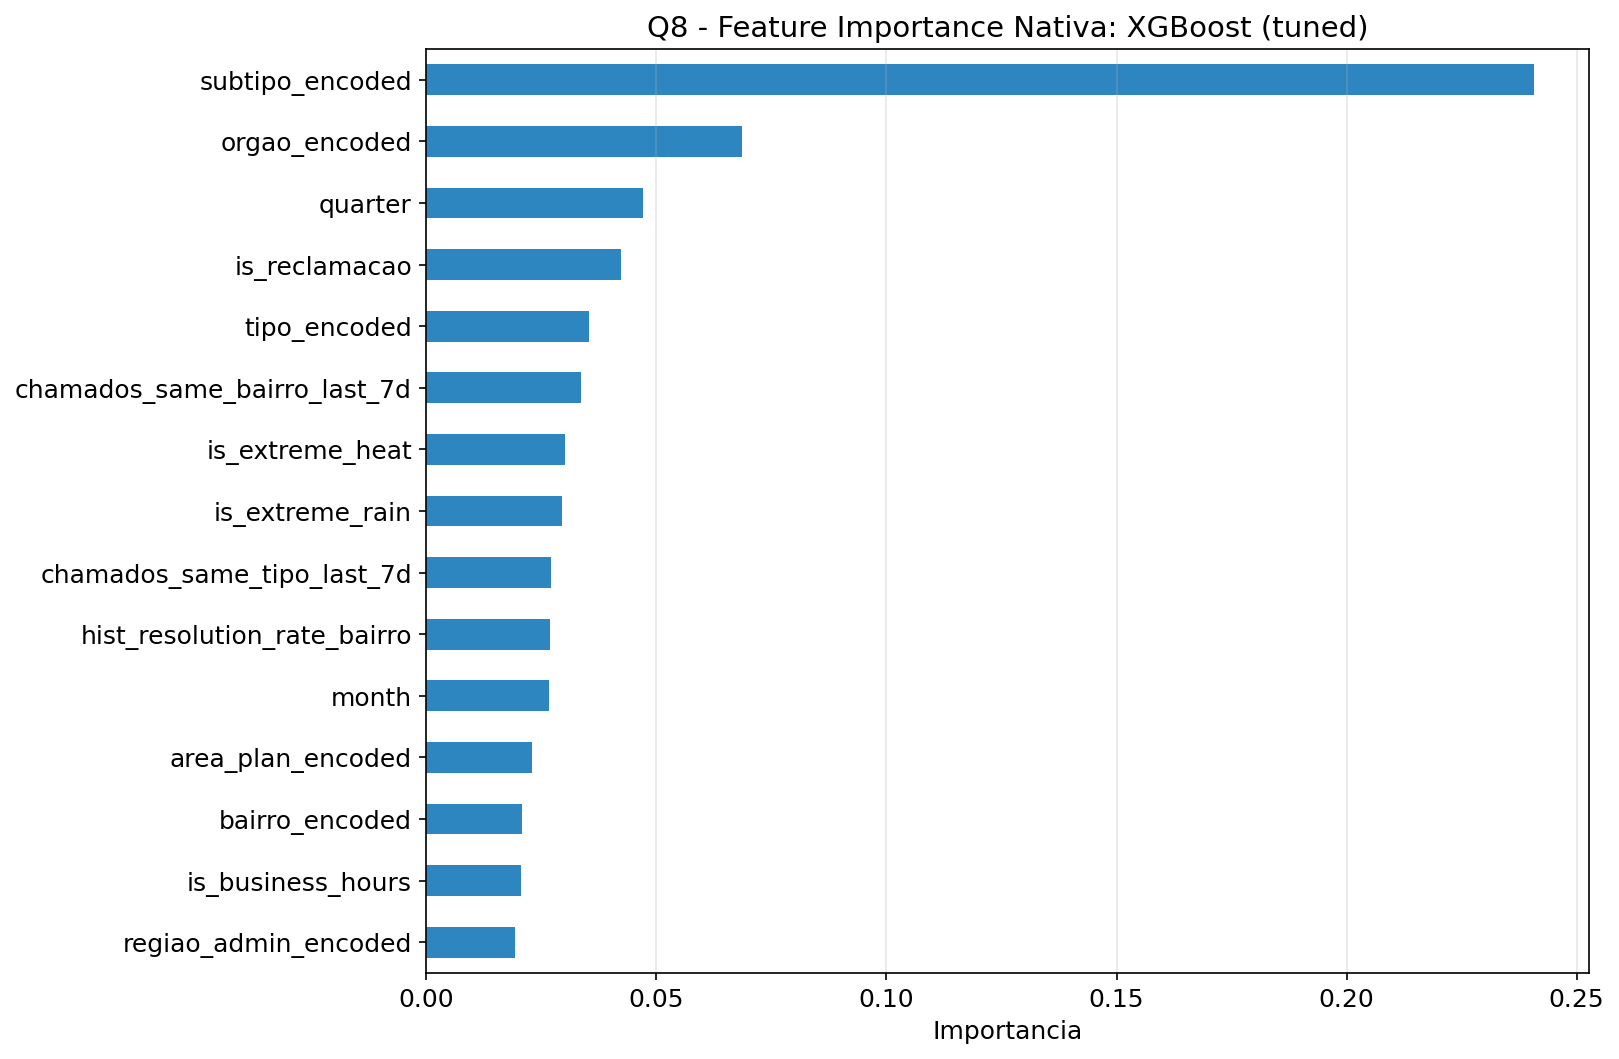

In [17]:
display(Image(filename='results/figures/q8_feature_importance.png'))

### Analise de Erros

| Tipo | Quantidade | Percentual |
|------|-----------|------------|
| Falsos Positivos (FP) | 2950 | 11.4% |
| Falsos Negativos (FN) | 1506 | 5.8% |

- **FP**: modelo previu resolucao em 7 dias, mas o chamado NAO foi resolvido.
- **FN**: modelo previu NAO resolucao, mas o chamado FOI resolvido.

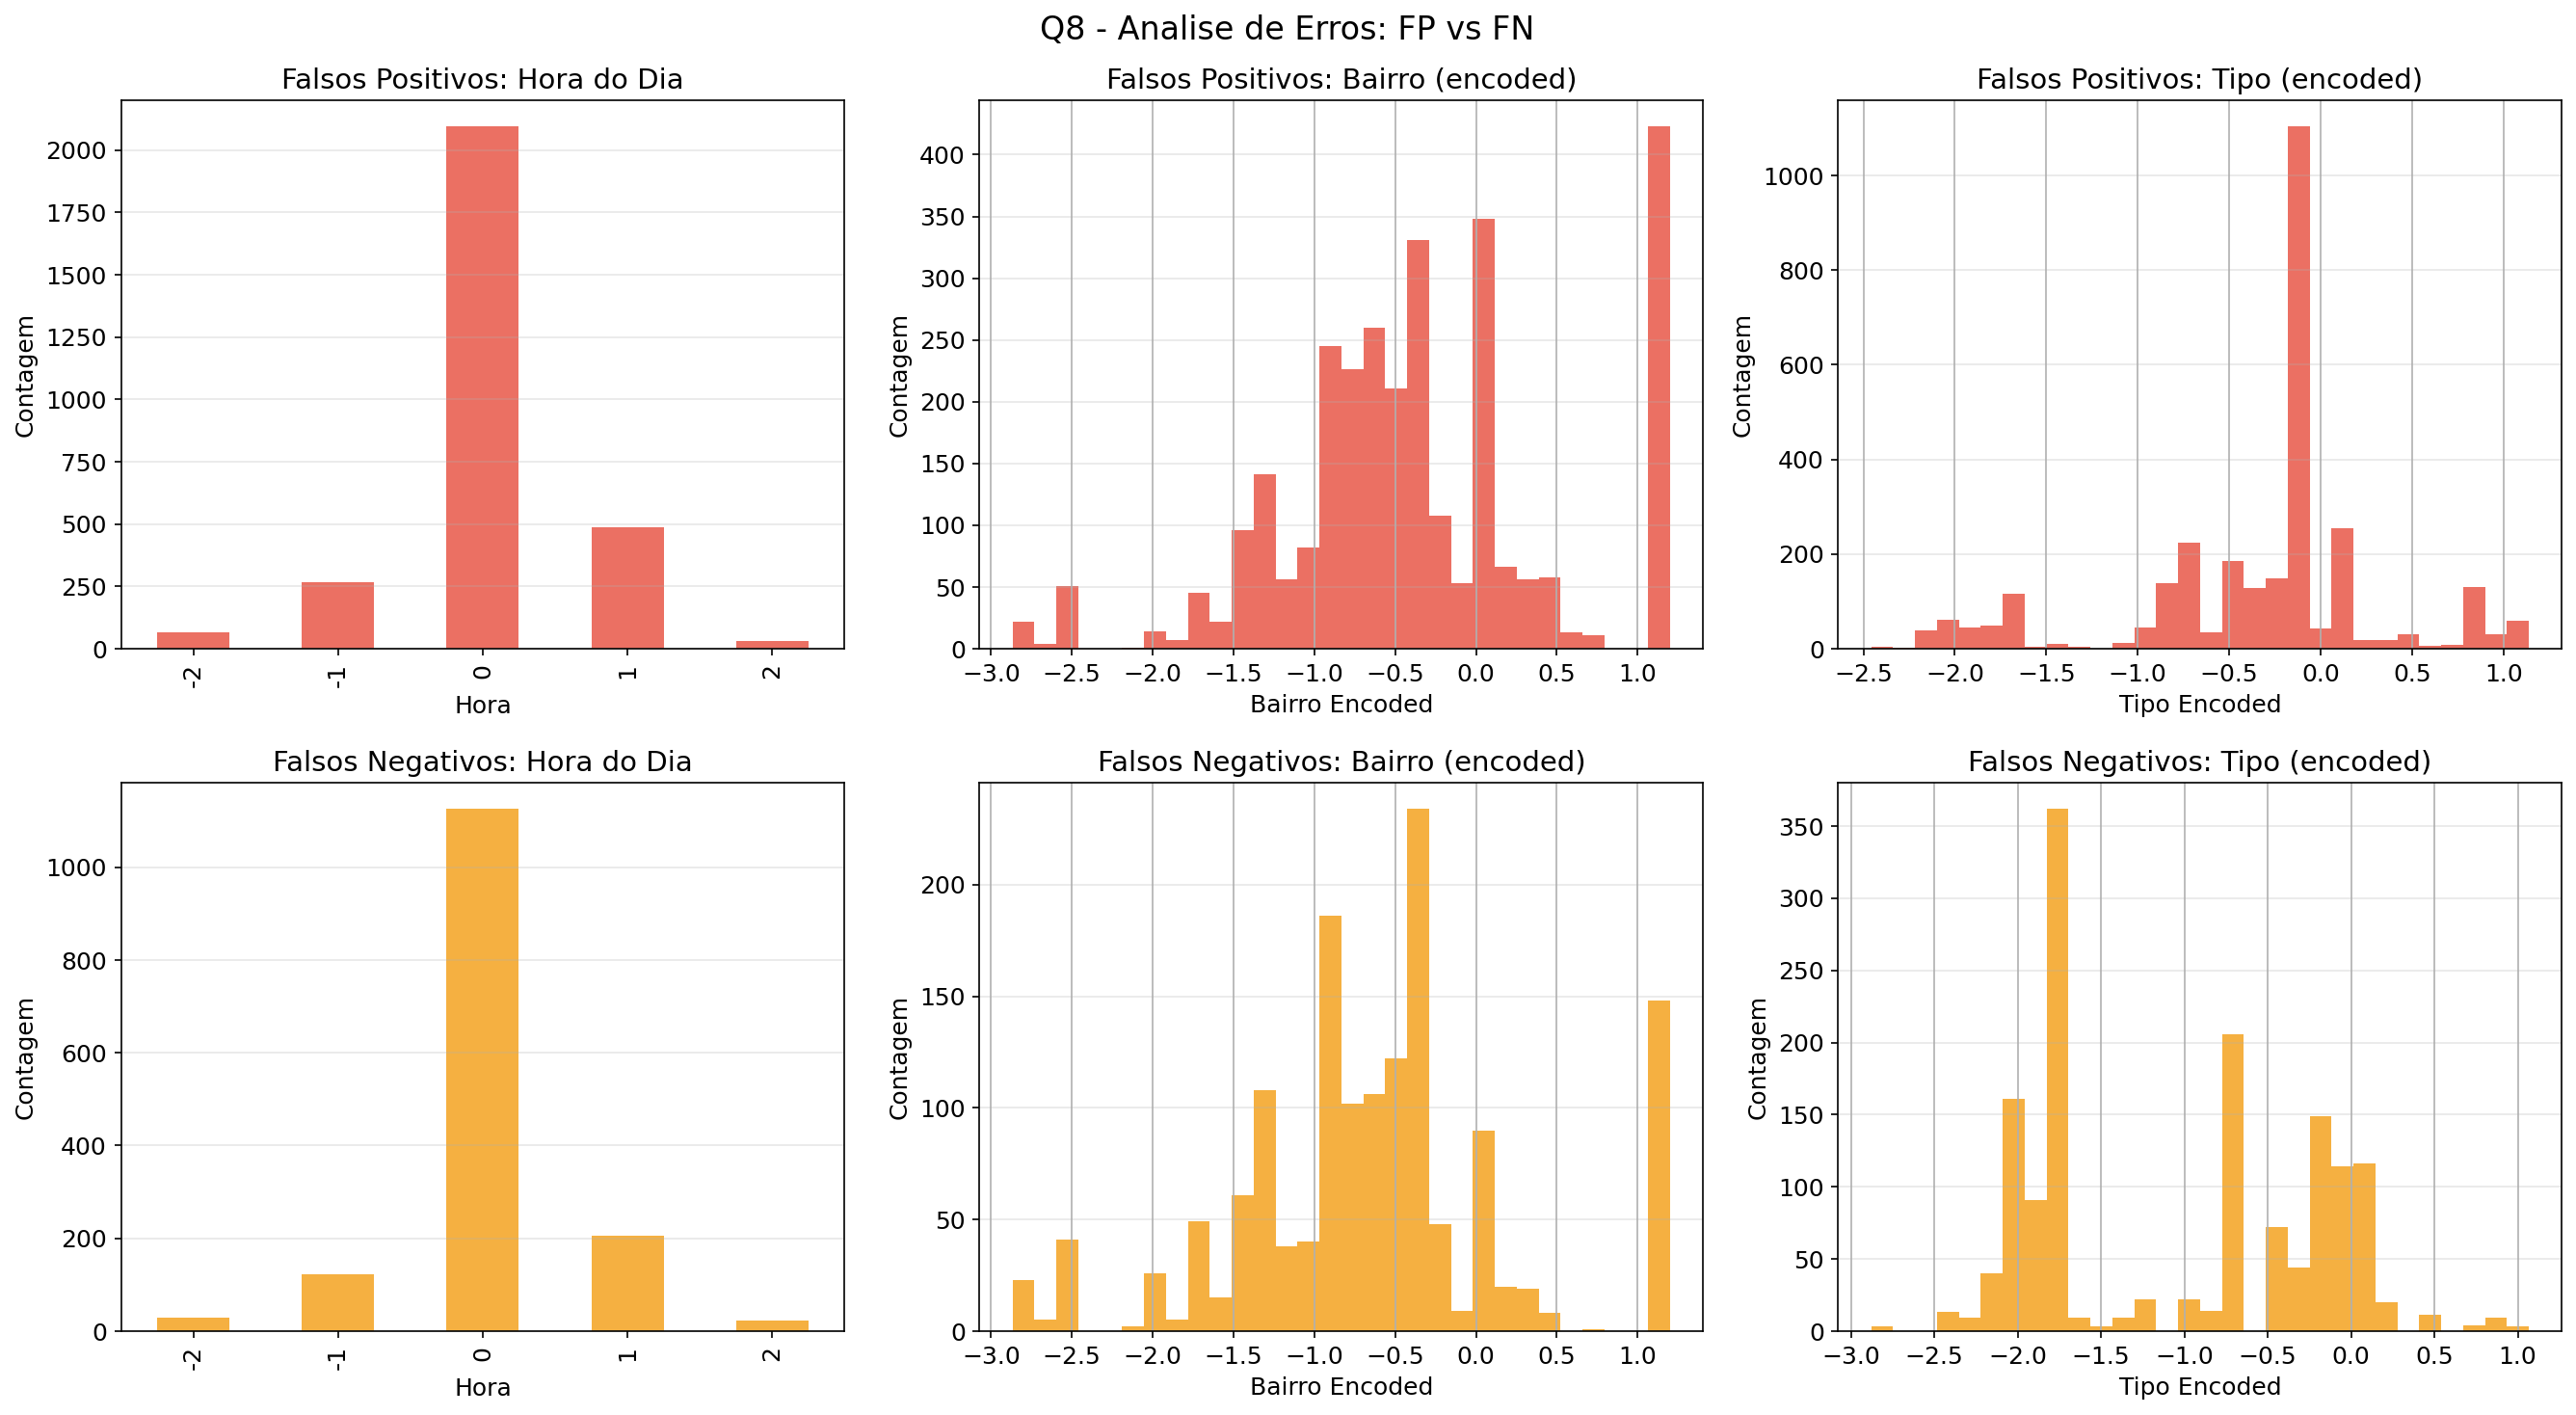

In [18]:
display(Image(filename='results/figures/q8_error_analysis.png'))

### O Que o Modelo Aprendeu

O subtipo e o órgão responsável dominam as predições — o que faz sentido: certos
tipos de serviço têm SLA muito diferente dos outros, e certos órgãos historicamente
resolvem mais rápido.

A taxa histórica de resolução do bairro (`hist_resolution_rate_bairro`) aparece forte
entre as top features, confirmando o que o Q2 mostrou: território importa.
O risco é que o modelo pode *perpetuar* disparidades territoriais — prever que chamados
de bairros com baixa resolução histórica vão atrasar, tornando isso uma profecia auto-realizável.

Variáveis climáticas entram no top 10 mas não dominam. Hora de abertura e dia da semana
têm mais peso do que temperatura ou precipitação — possivelmente porque a capacidade
de atendimento municipal varia mais pelo calendário do que pelo clima.
